# 04 Paretro: Pareto-based Lab Candidate Selection

This notebook implements a multi-objective candidate selection workflow
for generated NylC variants.

The filename keeps the requested `Paretro` spelling, but the method is
Pareto-based selection.

Goals:

- train a conservative descriptor-based ANOVA-GP ensemble from the
  current lab data;
- reconstruct mutations for generated BoltzGen candidates;
- score candidates by predicted PA6 activity, model uncertainty,
  structural quality, diversity, mutation burden and liability risk;
- compute separate exploitation, exploration and balanced Pareto fronts;
- select a diverse laboratory test panel plus controls;
- export all tables needed for the next design-build-test-learn round.

## Scientific caution

This workflow should be interpreted as **candidate prioritization**, not
as calibrated absolute prediction. The ANOVA-GP model is trained on a
small four-position lab dataset. Generated variants may contain
mutations outside those modeled positions, so predictions are best read
as pocket-projection scores. The Pareto workflow explicitly keeps
structure, diversity and mutation burden visible instead of collapsing
everything into a single optimized acquisition score.

In [30]:
# Run once in a fresh environment if peptides.py is missing.
# In the ba_nylc cluster environment this is usually already installed.
%pip install peptides

Note: you may need to restart the kernel to use updated packages.


In [31]:
from dataclasses import dataclass
from itertools import product
from pathlib import Path
import math
import re
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.distance import cdist
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import peptides
from peptides import Peptide

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)
rng = np.random.default_rng(42)


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [start] + list(start.parents):
        if (candidate / "matrices" / "NylC_Puetz_raw_data.CSV").exists():
            return candidate
    if start.name == "Notebooks":
        return start.parent
    raise FileNotFoundError("Could not locate project root.")


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "matrices" / "NylC_Puetz_raw_data.CSV"
WT_FASTA = PROJECT_ROOT / "inputs" / "variant_fastas" / "WT.fasta"
BOLTZ_DIR = PROJECT_ROOT / "inputs" / "boltz_variants"
OUT_DIR = PROJECT_ROOT / "results" / "paretro_selection"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Python:", sys.version.split()[0])
print("peptides.py:", getattr(peptides, "__version__", "unknown"))
print("Project root:", PROJECT_ROOT)
print("Output:", OUT_DIR)

Python: 3.9.21
peptides.py: 0.5.0
Project root: /rwthfs/rz/cluster/home/dwp46550/ba_nylon
Output: /rwthfs/rz/cluster/home/dwp46550/ba_nylon/results/paretro_selection


## Configuration

Adjust `LAB_PANEL_SIZE` and `MAX_MUTATIONS_HARD` before a real lab
round. The default panel uses 17 generated variants plus 3 controls.

In [32]:
LAB_PANEL_SIZE = 20
N_CONTROLS = 3
N_GENERATED_TO_SELECT = LAB_PANEL_SIZE - N_CONTROLS

MAX_MUTATIONS_HARD = 8
MAX_MUTATIONS_PREFERRED = 5
MAX_PER_MUTATION_SIGNATURE = 3
MIN_QUALITY_SCORE = 0.0

# Default final-model ensemble. These settings come from the reviewed
# ANOVA-GP sensitivity analysis and are deliberately simple.
ENSEMBLE_DESCRIPTOR_SETS = ["physical", "z_scales", "vhse", "kidera", "pcp", "atchley"]
DEFAULT_MODEL_SETTINGS = {
    "physical": {"lengthscale": 0.2, "sigma_main": 0.5, "sigma_epi": 4.0, "sigma_noise": 0.5},
    "z_scales": {"lengthscale": 0.5, "sigma_main": 0.5, "sigma_epi": 4.0, "sigma_noise": 0.5},
    "vhse": {"lengthscale": 0.5, "sigma_main": 0.5, "sigma_epi": 4.0, "sigma_noise": 0.5},
    "kidera": {"lengthscale": 0.2, "sigma_main": 0.5, "sigma_epi": 4.0, "sigma_noise": 0.5},
    "pcp": {"lengthscale": 0.2, "sigma_main": 0.5, "sigma_epi": 4.0, "sigma_noise": 0.5},
    "atchley": {"lengthscale": 0.2, "sigma_main": 0.5, "sigma_epi": 4.0, "sigma_noise": 0.5},
}

print("Generated candidates to select:", N_GENERATED_TO_SELECT)
print("Descriptor ensemble:", ENSEMBLE_DESCRIPTOR_SETS)

Generated candidates to select: 17
Descriptor ensemble: ['physical', 'z_scales', 'vhse', 'kidera', 'pcp', 'atchley']


## Load lab data and WT sequence

In [33]:
def read_fasta_sequence(path):
    return "".join(
        line.strip()
        for line in Path(path).read_text().splitlines()
        if line.strip() and not line.startswith(">")
    )


WT_SEQUENCE = read_fasta_sequence(WT_FASTA)
print("WT length:", len(WT_SEQUENCE))

df_raw = pd.read_csv(DATA_PATH, sep=";", decimal=",")
activity_rep_cols = [col for col in df_raw.columns if col.startswith("activity_pa6_")]
tm_rep_cols = [col for col in df_raw.columns if col.startswith("tm_celsius_")]

df_lab = df_raw.copy()
df_lab[activity_rep_cols] = df_lab[activity_rep_cols].apply(pd.to_numeric, errors="coerce")
df_lab[tm_rep_cols] = df_lab[tm_rep_cols].apply(pd.to_numeric, errors="coerce")
df_lab["activity_n"] = df_lab[activity_rep_cols].count(axis=1)
df_lab["activity_pa6"] = df_lab[activity_rep_cols].mean(axis=1, skipna=True)
df_lab["activity_sd"] = df_lab[activity_rep_cols].std(axis=1, skipna=True, ddof=1)
df_lab["activity_sem"] = df_lab["activity_sd"] / np.sqrt(df_lab["activity_n"])
df_lab["tm_celsius"] = df_lab[tm_rep_cols].mean(axis=1, skipna=True)

fallback_sem = df_lab.loc[
    df_lab["activity_sem"].notna() & (df_lab["activity_sem"] > 0),
    "activity_sem",
].median()
df_lab["activity_sem_for_gp"] = df_lab["activity_sem"].fillna(fallback_sem)

display(df_lab[["variant_id", "mutations", "activity_n", "activity_pa6", "activity_sem_for_gp", "tm_celsius"]].head(12))
print("Lab variants:", len(df_lab))

WT length: 355


,variant_id,mutations,activity_n,activity_pa6,activity_sem_for_gp,tm_celsius
0,WT,NaN,3,77.666667,1.333333,85.75
1,D99G,D99G,3,144.000000,11.150486,83.60
2,D99V,D99V,3,147.666667,3.480102,83.70
3,D99R,D99R,2,194.000000,10.000000,86.35
4,F134W,F134W,2,217.000000,5.000000,86.15
5,F301L,F301L,2,118.500000,3.500000,83.70
6,D304M,D304M,2,233.500000,2.500000,89.50
7,D304E,D304E,4,171.250000,4.516175,87.70
8,D304Q,D304Q,3,157.000000,6.429101,89.55
9,D304V,D304V,2,131.500000,13.500000,88.20


Lab variants: 36


## Descriptor-based ANOVA-GP model

This is a compact self-contained copy of the reviewed model logic. It
is used here for final candidate scoring, not for claiming a calibrated
absolute activity predictor.

In [34]:
CANONICAL_AA = tuple("ACDEFGHIKLMNPQRSTVWY")
WT_POCKET = {99: "D", 134: "F", 304: "D", 330: "R"}
POSITIONS = tuple(WT_POCKET.keys())
TARGET_POSITIONS = set(POSITIONS)

DESCRIPTOR_SOURCES = {
    "kidera": {"method": "kidera_factors", "columns": [f"KF{i}" for i in range(1, 11)]},
    "vhse": {"method": "vhse_scales", "columns": [f"VHSE{i}" for i in range(1, 9)]},
    "z_scales": {"method": "z_scales", "columns": [f"Z{i}" for i in range(1, 6)]},
    "atchley": {"method": "atchley_factors", "columns": [f"AF{i}" for i in range(1, 6)]},
    "pcp": {"method": "pcp_descriptors", "columns": [f"PCP{i}" for i in range(1, 6)]},
    "physical": {"method": "physical_descriptors", "columns": ["PD1", "PD2"]},
}


@dataclass(frozen=True)
class DescriptorSource:
    name: str
    method: str
    raw_table: pd.DataFrame
    scaled_table: pd.DataFrame


def residue_descriptor_table(source_name, standardize=True):
    cfg = DESCRIPTOR_SOURCES[source_name]
    rows = {}
    for aa in CANONICAL_AA:
        values = np.asarray(getattr(Peptide(aa), cfg["method"])(), dtype=float)
        rows[aa] = values
    raw = pd.DataFrame.from_dict(rows, orient="index", columns=cfg["columns"]).sort_index()
    if standardize:
        scaled = pd.DataFrame(StandardScaler().fit_transform(raw), index=raw.index, columns=raw.columns)
    else:
        scaled = raw.copy()
    return DescriptorSource(source_name, cfg["method"], raw, scaled)


DESCRIPTOR_CACHE = {}


def get_descriptor_source(source_name):
    if source_name not in DESCRIPTOR_CACHE:
        DESCRIPTOR_CACHE[source_name] = residue_descriptor_table(source_name, standardize=True)
    return DESCRIPTOR_CACHE[source_name]


MUTATION_PATTERN = re.compile(r"([A-Z])(\d+)([A-Z])")


def parse_mutation_string(mutation_string):
    if pd.isna(mutation_string) or str(mutation_string).strip().lower() in {"", "wt", "wildtype", "wild type", "nan"}:
        return []
    return [(wt, int(pos), mut) for wt, pos, mut in MUTATION_PATTERN.findall(str(mutation_string).upper())]


def mutation_list_to_string(mutations):
    if not mutations:
        return ""
    return ";".join(f"{wt}{pos}{mut}" for wt, pos, mut in sorted(mutations, key=lambda x: x[1]))


def pocket_from_mutations(mutations):
    pocket = dict(WT_POCKET)
    for wt, pos, mut in mutations:
        if pos in pocket:
            pocket[pos] = mut
    return pocket


def mutation_positions(mutations):
    return {pos for _, pos, _ in mutations}


def mutation_signature(positions):
    if not positions:
        return "WT"
    return "+".join(str(pos) for pos in sorted(positions))


def add_mutation_features(df, mutation_col="mutations"):
    out = df.copy()
    parsed = out[mutation_col].apply(parse_mutation_string)
    out["parsed_mutations"] = parsed
    out["mutation_set"] = parsed.apply(lambda muts: frozenset(f"{wt}{pos}{mut}" for wt, pos, mut in muts))
    out["n_mutations_reconstructed"] = parsed.apply(len)
    out["mutation_positions"] = parsed.apply(mutation_positions)
    out["mutation_signature"] = out["mutation_positions"].apply(mutation_signature)
    out["pocket"] = parsed.apply(pocket_from_mutations)
    out["aa_tuple"] = out["pocket"].apply(lambda pocket: tuple(pocket[pos] for pos in POSITIONS))
    out["only_gp_target_positions"] = out["mutation_positions"].apply(lambda pos: pos.issubset(TARGET_POSITIONS))
    out["n_external_mutations"] = out["parsed_mutations"].apply(lambda muts: sum(pos not in TARGET_POSITIONS for _, pos, _ in muts))
    return out


df_lab_model = add_mutation_features(df_lab, "mutations")
df_train_gp = df_lab_model[df_lab_model["only_gp_target_positions"]].copy().reset_index(drop=True)
print("GP training variants:", len(df_train_gp), "of", len(df_lab_model))
display(df_train_gp[["variant_id", "mutations", "aa_tuple", "activity_pa6"]].head())

GP training variants: 35 of 36


,variant_id,mutations,aa_tuple,activity_pa6
0,WT,NaN,"(D, F, D, R)",77.666667
1,D99G,D99G,"(G, F, D, R)",144.000000
2,D99V,D99V,"(V, F, D, R)",147.666667
3,D99R,D99R,"(R, F, D, R)",194.000000
4,F134W,F134W,"(D, W, D, R)",217.000000


In [35]:
def aa_descriptor_vector(aa, source):
    return source.scaled_table.loc[str(aa).upper()].to_numpy(dtype=float)


def pockets_to_position_descriptor_arrays(pockets, source, positions=POSITIONS):
    return {
        pos: np.vstack([aa_descriptor_vector(pocket[pos], source) for pocket in pockets])
        for pos in positions
    }


def rbf_kernel_from_descriptors(X1, X2=None, lengthscale=1.0):
    if X2 is None:
        X2 = X1
    X1 = np.asarray(X1, dtype=float)
    X2 = np.asarray(X2, dtype=float)
    squared_distances = ((X1[:, None, :] - X2[None, :, :]) ** 2).sum(axis=2)
    return np.exp(-squared_distances / (2.0 * float(lengthscale) ** 2))


def build_position_kernels(position_arrays, lengthscale=1.0):
    return {
        pos: rbf_kernel_from_descriptors(values, lengthscale=lengthscale)
        for pos, values in position_arrays.items()
    }


def build_position_cross_kernels(train_pockets, test_pockets, source, lengthscale=1.0):
    train_arrays = pockets_to_position_descriptor_arrays(train_pockets, source)
    test_arrays = pockets_to_position_descriptor_arrays(test_pockets, source)
    return {
        pos: rbf_kernel_from_descriptors(test_arrays[pos], X2=train_arrays[pos], lengthscale=lengthscale)
        for pos in POSITIONS
    }


def build_main_kernel(position_kernels):
    return np.mean(np.stack(list(position_kernels.values()), axis=0), axis=0)


def build_epistasis_kernel(position_kernels):
    positions = list(position_kernels)
    products = []
    for i, pos_a in enumerate(positions):
        for pos_b in positions[i + 1:]:
            products.append(position_kernels[pos_a] * position_kernels[pos_b])
    return np.mean(np.stack(products, axis=0), axis=0)


def build_total_anova_kernel(position_kernels, sigma_main=0.5, sigma_epi=4.0):
    return float(sigma_main) ** 2 * build_main_kernel(position_kernels) + float(sigma_epi) ** 2 * build_epistasis_kernel(position_kernels)


def build_total_cross_kernel(train_pockets, test_pockets, source, lengthscale=1.0, sigma_main=0.5, sigma_epi=4.0):
    cross = build_position_cross_kernels(train_pockets, test_pockets, source, lengthscale=lengthscale)
    return float(sigma_main) ** 2 * build_main_kernel(cross) + float(sigma_epi) ** 2 * build_epistasis_kernel(cross)


def standardize_target(y):
    y = np.asarray(y, dtype=float)
    y_mean = float(np.mean(y))
    y_std = float(np.std(y, ddof=1))
    return (y - y_mean) / y_std, y_mean, y_std


def fit_gp_from_kernel(K_total, y, sem=None, sigma_noise=0.5, jitter=1e-8):
    y_scaled, y_mean, y_std = standardize_target(y)
    n = len(y_scaled)
    if sem is None:
        sem_scaled = np.zeros(n)
    else:
        sem_scaled = np.nan_to_num(np.asarray(sem, dtype=float) / y_std, nan=0.0)
    K_y = (
        K_total
        + np.diag(sem_scaled ** 2)
        + float(sigma_noise) ** 2 * np.eye(n)
        + float(jitter) * np.eye(n)
    )
    L = np.linalg.cholesky(K_y)
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_scaled))
    return {
        "K_total": K_total,
        "K_y": K_y,
        "L": L,
        "alpha": alpha,
        "y_mean": y_mean,
        "y_std": y_std,
        "sigma_noise": float(sigma_noise),
    }


def gp_predict_from_fit(gp_fit, K_test_train, K_test_diag):
    mean_scaled = K_test_train @ gp_fit["alpha"]
    v = np.linalg.solve(gp_fit["L"], K_test_train.T)
    var_latent_scaled = np.maximum(K_test_diag - np.sum(v ** 2, axis=0), 0.0)
    var_observed_scaled = var_latent_scaled + gp_fit["sigma_noise"] ** 2
    return {
        "mean": gp_fit["y_mean"] + gp_fit["y_std"] * mean_scaled,
        "std_observed": gp_fit["y_std"] * np.sqrt(var_observed_scaled),
    }


def fit_final_gp_model(df_train, source_name, settings):
    source = get_descriptor_source(source_name)
    train_pockets = df_train["pocket"].tolist()
    arrays = pockets_to_position_descriptor_arrays(train_pockets, source)
    kernels = build_position_kernels(arrays, lengthscale=settings["lengthscale"])
    K_train = build_total_anova_kernel(kernels, sigma_main=settings["sigma_main"], sigma_epi=settings["sigma_epi"])
    fit = fit_gp_from_kernel(
        K_train,
        y=df_train["activity_pa6"].to_numpy(dtype=float),
        sem=df_train["activity_sem_for_gp"].to_numpy(dtype=float),
        sigma_noise=settings["sigma_noise"],
    )
    return {"source_name": source_name, "source": source, "settings": settings, "train_pockets": train_pockets, "fit": fit}


def predict_with_final_gp_model(model, candidate_pockets):
    settings = model["settings"]
    K_test_train = build_total_cross_kernel(
        model["train_pockets"],
        candidate_pockets,
        source=model["source"],
        lengthscale=settings["lengthscale"],
        sigma_main=settings["sigma_main"],
        sigma_epi=settings["sigma_epi"],
    )
    K_test_diag = np.full(len(candidate_pockets), float(settings["sigma_main"]) ** 2 + float(settings["sigma_epi"]) ** 2)
    return gp_predict_from_fit(model["fit"], K_test_train, K_test_diag)


final_models = {
    source_name: fit_final_gp_model(df_train_gp, source_name, DEFAULT_MODEL_SETTINGS[source_name])
    for source_name in ENSEMBLE_DESCRIPTOR_SETS
}
print("Fitted final descriptor models:", list(final_models))

Fitted final descriptor models: ['physical', 'z_scales', 'vhse', 'kidera', 'pcp', 'atchley']


## Load generated BoltzGen candidates

Raw BoltzGen tables do not always include a clean mutation column.
Mutations are reconstructed by aligning each designed fragment to the
WT sequence with a simple offset scan. `X` is treated as unknown and
ignored during comparison.

In [36]:
BOLTZGEN_POSITION_MAP = [
    ("full_sequence_0", 82, 99),
    ("full_sequence_0", 117, 134),
    ("full_sequence_3", 38, 304),
    ("full_sequence_7", 64, 330),
]

# Use all design tables by default. For debugging a single run, set this to
# e.g. "all_designs_metrics_NylC_paper.csv".
CANDIDATE_CSV_PATTERN = "final_designs_metrics_160.csv"


def load_boltzgen_candidate_csvs(candidate_dir=BOLTZ_DIR, csv_pattern=CANDIDATE_CSV_PATTERN):
    candidate_dir = Path(candidate_dir)
    if not candidate_dir.exists():
        raise FileNotFoundError(f"Candidate directory does not exist: {candidate_dir}")

    csv_files = sorted(candidate_dir.glob(csv_pattern))
    if len(csv_files) == 0:
        available_csvs = sorted(candidate_dir.rglob(".csv"))
        msg = (
            f"No candidate CSV files found in {candidate_dir} "
            f"with pattern {csv_pattern}.\n\nAvailable CSV files:\n"
        )
        msg += "\n".join(str(file) for file in available_csvs[:50]) if available_csvs else "No CSV files found at all."
        raise FileNotFoundError(msg)

    print("Loaded candidate CSV files:")
    dfs = []
    for csv_file in csv_files:
        print(" ", csv_file)
        tmp = pd.read_csv(csv_file)
        tmp["source_file"] = csv_file.name
        tmp["source_path"] = str(csv_file)
        tmp["boltzgen_run"] = csv_file.stem.replace("final_designs_metrics_160", "")
        dfs.append(tmp)

    return pd.concat(dfs, ignore_index=True, sort=False)


def validate_required_boltzgen_columns(df, position_map=BOLTZGEN_POSITION_MAP):
    required_cols = sorted(set(col for col, _, _ in position_map))
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError("Missing required BoltzGen sequence columns: " + ", ".join(missing_cols))

    print("Required sequence columns found:")
    for col in required_cols:
        lengths = df[col].dropna().astype(str).str.len()
        print(
            col,
            "min_len:", lengths.min(),
            "max_len:", lengths.max(),
            "unique_sequences:", df[col].nunique(),
        )


def get_aa_from_chain_sequence(row, sequence_col, local_pos):
    if sequence_col not in row.index:
        return None, f"missing_column_{sequence_col}"
    seq = row[sequence_col]
    if pd.isna(seq):
        return None, f"missing_value_{sequence_col}"

    seq = str(seq).strip().upper()
    if len(seq) < local_pos:
        return None, f"{sequence_col}_too_short_for_position_{local_pos}"

    aa = seq[local_pos - 1]
    if aa not in CANONICAL_AA:
        return None, f"noncanonical_{aa}_in_{sequence_col}_at_{local_pos}"

    return aa, "ok"


def extract_boltzgen_pocket_from_chain_sequences(row, position_map=BOLTZGEN_POSITION_MAP, wt_pocket=WT_POCKET):
    pocket = {}
    mutations = []
    status_messages = []

    for sequence_col, local_pos, model_pos in position_map:
        aa, status = get_aa_from_chain_sequence(row, sequence_col, local_pos)
        if status != "ok":
            status_messages.append(status)
            continue

        pocket[model_pos] = aa
        wt_aa = wt_pocket[model_pos]
        if aa != wt_aa:
            mutations.append((wt_aa, model_pos, aa))

    expected_positions = set(POSITIONS)
    if set(pocket.keys()) != expected_positions:
        return None, "incomplete_pocket", None, None

    if status_messages:
        return None, ";".join(status_messages), None, None

    mutated_positions = tuple(pos for _, pos, _ in mutations)
    return pocket, "ok", mutations, mutated_positions


def add_boltzgen_candidates_from_full_sequences(df):
    df = df.copy()
    validate_required_boltzgen_columns(df, BOLTZGEN_POSITION_MAP)

    if "id" in df.columns:
        df["candidate_id"] = df["boltzgen_run"].astype(str) + "__" + df["id"].astype(str)
    else:
        df["candidate_id"] = [f"candidate_{i:05d}" for i in range(len(df))]

    pockets = []
    statuses = []
    mutations = []
    mutation_strings = []
    mutated_positions = []

    for _, row in df.iterrows():
        pocket, status, mutation_list, pos_tuple = extract_boltzgen_pocket_from_chain_sequences(row)
        pockets.append(pocket)
        statuses.append(status)
        mutations.append(mutation_list if mutation_list is not None else [])
        mutation_strings.append(mutation_list_to_string(mutation_list or []))
        mutated_positions.append(pos_tuple)

    df["pocket"] = pockets
    df["candidate_status"] = statuses
    df["parsed_mutations"] = mutations
    df["mutations"] = mutation_strings
    df["mutated_positions"] = mutated_positions

    df_valid = df[df["candidate_status"].eq("ok")].copy()
    df_valid["aa_tuple"] = df_valid["pocket"].apply(lambda pocket: tuple(pocket[pos] for pos in POSITIONS))
    for pos in POSITIONS:
        df_valid[f"aa{pos}"] = df_valid["pocket"].apply(lambda pocket, pos=pos: pocket[pos])

    df_valid["n_target_mutations"] = df_valid["parsed_mutations"].apply(len)
    df_valid["n_mutations"] = df_valid["n_target_mutations"]
    df_valid["mutation_positions"] = df_valid["parsed_mutations"].apply(mutation_positions)
    df_valid["mutation_signature"] = df_valid["mutation_positions"].apply(mutation_signature)
    df_valid["mutation_set"] = df_valid["parsed_mutations"].apply(
        lambda muts: frozenset(f"{wt}{pos}{mut}" for wt, pos, mut in muts)
    )
    df_valid["only_gp_target_positions"] = True
    df_valid["n_external_mutations"] = 0

    # Deduplicate identical four-position pockets across BoltzGen runs, keeping
    # the structurally strongest representative.
    sort_cols = [col for col in ["quality_score", "design_to_target_iptm", "design_ptm"] if col in df_valid.columns]
    if sort_cols:
        df_valid = df_valid.sort_values(sort_cols, ascending=[False] * len(sort_cols))
    df_valid = df_valid.drop_duplicates(subset=["aa_tuple"], keep="first").reset_index(drop=True)

    return df, df_valid


def check_designed_sequence_consistency(df_valid, strict=True):
    if "designed_sequence" not in df_valid.columns:
        print("Column designed_sequence not found. Skipping consistency check.")
        return df_valid

    df_check = df_valid.copy()
    df_check["designed_sequence_clean"] = df_check["designed_sequence"].astype(str).str.strip().str.upper()
    df_check["extracted_designed_sequence"] = (
        df_check["aa99"] + df_check["aa134"] + df_check["aa304"] + df_check["aa330"]
    )
    df_check["designed_sequence_matches"] = (
        df_check["designed_sequence_clean"] == df_check["extracted_designed_sequence"]
    )

    match_fraction = df_check["designed_sequence_matches"].mean()
    n_mismatches = int((~df_check["designed_sequence_matches"]).sum())
    print("\nDesigned-sequence consistency:")
    print("Expected order: aa99 + aa134 + aa304 + aa330")
    print("Match fraction:", match_fraction)
    print("Number of mismatches:", n_mismatches)

    display(
        df_check[
            [
                "candidate_id",
                "designed_sequence_clean",
                "extracted_designed_sequence",
                "designed_sequence_matches",
                "mutations",
                "aa99",
                "aa134",
                "aa304",
                "aa330",
            ]
        ].head(30)
    )

    if strict and n_mismatches > 0:
        display(
            df_check.loc[
                ~df_check["designed_sequence_matches"],
                [
                    "candidate_id",
                    "designed_sequence_clean",
                    "extracted_designed_sequence",
                    "mutations",
                    "aa99",
                    "aa134",
                    "aa304",
                    "aa330",
                    "source_file",
                ],
            ]
        )
        raise ValueError(
            "designed_sequence does not match extracted amino acids. "
            "Check BOLTZGEN_POSITION_MAP or chain numbering."
        )

    return df_check


boltzgen_candidates_raw = load_boltzgen_candidate_csvs(
    candidate_dir=BOLTZ_DIR,
    csv_pattern=CANDIDATE_CSV_PATTERN,
)
boltzgen_candidates_all, boltzgen_candidates_valid = add_boltzgen_candidates_from_full_sequences(
    boltzgen_candidates_raw
)
boltzgen_candidates_valid_checked = check_designed_sequence_consistency(
    boltzgen_candidates_valid,
    strict=True,
)

candidates = boltzgen_candidates_valid_checked.copy()

tested_mutation_sets = set(df_lab_model["mutation_set"])
candidates["already_tested"] = candidates["mutation_set"].isin(tested_mutation_sets)

print("\nRaw BoltzGen candidates:", boltzgen_candidates_raw.shape)
print("Candidates after extraction:", boltzgen_candidates_all.shape)
print("Valid deduplicated ANOVA-GP candidates:", candidates.shape)
print("\nCandidate status counts:")
print(boltzgen_candidates_all["candidate_status"].value_counts(dropna=False))
print("\nMutation count distribution:")
print(candidates["n_target_mutations"].value_counts(dropna=False).sort_index())

display(
    candidates[
        [
            "candidate_id",
            "mutations",
            "mutated_positions",
            "aa99",
            "aa134",
            "aa304",
            "aa330",
            "n_target_mutations",
            "source_file",
        ]
    ].head(30)
)

Loaded candidate CSV files:
  /rwthfs/rz/cluster/home/dwp46550/ba_nylon/inputs/boltz_variants/final_designs_metrics_160.csv
Required sequence columns found:
full_sequence_0 min_len: 243 max_len: 243 unique_sequences: 47
full_sequence_3 min_len: 89 max_len: 89 unique_sequences: 6
full_sequence_7 min_len: 89 max_len: 89 unique_sequences: 8

Designed-sequence consistency:
Expected order: aa99 + aa134 + aa304 + aa330
Match fraction: 1.0
Number of mismatches: 0


,candidate_id,designed_sequence_clean,extracted_designed_sequence,designed_sequence_matches,mutations,aa99,aa134,aa304,aa330
0,__task-1372632-1_NylC_paper_48,DPLG,DPLG,True,F134P;D304L;R330G,D,P,L,G
1,__task-1372632-25_NylC_paper_21,SFLA,SFLA,True,D99S;D304L;R330A,S,F,L,A
2,__task-1372632-105_NylC_paper_15,DFLG,DFLG,True,D304L;R330G,D,F,L,G
3,__task-1372632-10_NylC_paper_18,SILG,SILG,True,D99S;F134I;D304L;R330G,S,I,L,G
4,__task-1372632-104_NylC_paper_01,DFLS,DFLS,True,D304L;R330S,D,F,L,S
5,__task-1372632-91_NylC_paper_06,DVLS,DVLS,True,F134V;D304L;R330S,D,V,L,S
6,__task-1372632-132_NylC_paper_10,AFLG,AFLG,True,D99A;D304L;R330G,A,F,L,G
7,__task-1372632-40_NylC_paper_48,EFLS,EFLS,True,D99E;D304L;R330S,E,F,L,S
8,__task-1372632-103_NylC_paper_42,NPLG,NPLG,True,D99N;F134P;D304L;R330G,N,P,L,G
9,__task-1372632-22_NylC_paper_45,GPLN,GPLN,True,D99G;F134P;D304L;R330N,G,P,L,N



Raw BoltzGen candidates: (160, 217)
Candidates after extraction: (160, 223)
Valid deduplicated ANOVA-GP candidates: (160, 239)

Candidate status counts:
candidate_status
ok    160
Name: count, dtype: int64

Mutation count distribution:
n_target_mutations
2    11
3    92
4    57
Name: count, dtype: int64


,candidate_id,mutations,mutated_positions,aa99,aa134,aa304,aa330,n_target_mutations,source_file
0,__task-1372632-1_NylC_paper_48,F134P;D304L;R330G,"(134, 304, 330)",D,P,L,G,3,final_designs_metrics_160.csv
1,__task-1372632-25_NylC_paper_21,D99S;D304L;R330A,"(99, 304, 330)",S,F,L,A,3,final_designs_metrics_160.csv
2,__task-1372632-105_NylC_paper_15,D304L;R330G,"(304, 330)",D,F,L,G,2,final_designs_metrics_160.csv
3,__task-1372632-10_NylC_paper_18,D99S;F134I;D304L;R330G,"(99, 134, 304, 330)",S,I,L,G,4,final_designs_metrics_160.csv
4,__task-1372632-104_NylC_paper_01,D304L;R330S,"(304, 330)",D,F,L,S,2,final_designs_metrics_160.csv
5,__task-1372632-91_NylC_paper_06,F134V;D304L;R330S,"(134, 304, 330)",D,V,L,S,3,final_designs_metrics_160.csv
6,__task-1372632-132_NylC_paper_10,D99A;D304L;R330G,"(99, 304, 330)",A,F,L,G,3,final_designs_metrics_160.csv
7,__task-1372632-40_NylC_paper_48,D99E;D304L;R330S,"(99, 304, 330)",E,F,L,S,3,final_designs_metrics_160.csv
8,__task-1372632-103_NylC_paper_42,D99N;F134P;D304L;R330G,"(99, 134, 304, 330)",N,P,L,G,4,final_designs_metrics_160.csv
9,__task-1372632-22_NylC_paper_45,D99G;F134P;D304L;R330N,"(99, 134, 304, 330)",G,P,L,N,4,final_designs_metrics_160.csv


## Predict generated candidates with descriptor ensemble

In [37]:
candidate_pockets = candidates["pocket"].tolist()
ensemble_prediction_tables = []

for source_name, model in final_models.items():
    pred = predict_with_final_gp_model(model, candidate_pockets)
    ensemble_prediction_tables.append(pd.DataFrame({
        "candidate_id": candidates["candidate_id"].values,
        f"pred_activity_{source_name}": pred["mean"],
        f"pred_std_{source_name}": pred["std_observed"],
    }))

predictions = ensemble_prediction_tables[0]
for table in ensemble_prediction_tables[1:]:
    predictions = predictions.merge(table, on="candidate_id", how="left")

pred_cols = [c for c in predictions.columns if c.startswith("pred_activity_")]
std_cols = [c for c in predictions.columns if c.startswith("pred_std_")]

predictions["predicted_activity_gp_mean"] = predictions[pred_cols].mean(axis=1)
predictions["predicted_activity_gp_sd_between_descriptors"] = predictions[pred_cols].std(axis=1)
predictions["predicted_activity_gp_std_mean"] = predictions[std_cols].mean(axis=1)
predictions["model_uncertainty"] = np.sqrt(
    predictions["predicted_activity_gp_sd_between_descriptors"].fillna(0) ** 2
    + predictions["predicted_activity_gp_std_mean"].fillna(0) ** 2
)

candidates = candidates.merge(predictions, on="candidate_id", how="left")
display(candidates[["candidate_id", "mutations", "predicted_activity_gp_mean", "model_uncertainty"]].head())

,candidate_id,mutations,predicted_activity_gp_mean,model_uncertainty
0,__task-1372632-1_NylC_paper_48,F134P;D304L;R330G,258.388680,413.383221
1,__task-1372632-25_NylC_paper_21,D99S;D304L;R330A,153.490971,387.814234
2,__task-1372632-105_NylC_paper_15,D304L;R330G,156.719629,351.182857
3,__task-1372632-10_NylC_paper_18,D99S;F134I;D304L;R330G,240.216558,426.741916
4,__task-1372632-104_NylC_paper_01,D304L;R330S,156.608100,351.076082


## Scoring helpers: structure, novelty, diversity and filters

In [38]:
def robust_z(series, higher_is_better=True):
    s = pd.to_numeric(series, errors="coerce")
    med = s.median()
    mad = (s - med).abs().median()
    if not np.isfinite(mad) or mad == 0:
        std = s.std(ddof=0)
        z = (s - med) / std if std and np.isfinite(std) else pd.Series(0.0, index=s.index)
    else:
        z = 0.6745 * (s - med) / mad
    z = z.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return z if higher_is_better else -z


def safe_numeric_col(df, col, default=np.nan):
    if col in df.columns:
        return pd.to_numeric(df[col], errors="coerce")
    return pd.Series(default, index=df.index)


candidates["structure_score"] = (
    robust_z(safe_numeric_col(candidates, "quality_score"), True)
    + robust_z(safe_numeric_col(candidates, "design_to_target_iptm"), True)
    + robust_z(safe_numeric_col(candidates, "design_ptm"), True)
    + robust_z(safe_numeric_col(candidates, "filter_rmsd"), False)
    + robust_z(safe_numeric_col(candidates, "min_design_to_target_pae"), False)
    + robust_z(safe_numeric_col(candidates, "liability_score"), False)
)

candidates["mutation_burden"] = candidates["n_mutations"]
candidates["mutation_count_penalty"] = np.maximum(0, candidates["n_mutations"] - MAX_MUTATIONS_PREFERRED)
candidates["liability_score_numeric"] = safe_numeric_col(candidates, "liability_score", default=0).fillna(0)
candidates["quality_score_numeric"] = safe_numeric_col(candidates, "quality_score", default=0).fillna(0)

def jaccard_distance(set_a, set_b):
    set_a = set(set_a)
    set_b = set(set_b)
    if not set_a and not set_b:
        return 0.0
    return 1.0 - len(set_a & set_b) / len(set_a | set_b)


tested_sets = list(df_lab_model["mutation_set"])
candidates["diversity_from_tested"] = candidates["mutation_set"].apply(
    lambda s: min(jaccard_distance(s, tested) for tested in tested_sets)
)

candidates["has_x_filter_fail"] = (
    candidates["has_x"].astype(bool)
    if "has_x" in candidates.columns
    else False
)
candidates["hard_filter_pass"] = (
    (~candidates["already_tested"])
    & (candidates["n_mutations"] <= MAX_MUTATIONS_HARD)
    & (~candidates["has_x_filter_fail"])
    & (candidates["quality_score_numeric"] >= MIN_QUALITY_SCORE)
)

display(candidates[[
    "candidate_id", "mutations", "n_mutations", "hard_filter_pass",
    "predicted_activity_gp_mean", "model_uncertainty", "structure_score",
    "diversity_from_tested", "quality_score_numeric", "liability_score_numeric",
]].head(12))
print("Candidates passing hard filters:", candidates["hard_filter_pass"].sum(), "of", len(candidates))

,candidate_id,mutations,n_mutations,hard_filter_pass,predicted_activity_gp_mean,model_uncertainty,structure_score,diversity_from_tested,quality_score_numeric,liability_score_numeric
0,__task-1372632-1_NylC_paper_48,F134P;D304L;R330G,3,True,258.388680,413.383221,20.346983,0.666667,1.000000,275
1,__task-1372632-25_NylC_paper_21,D99S;D304L;R330A,3,True,153.490971,387.814234,20.599635,0.666667,0.996753,275
2,__task-1372632-105_NylC_paper_15,D304L;R330G,2,True,156.719629,351.182857,20.583664,0.500000,0.993506,275
3,__task-1372632-10_NylC_paper_18,D99S;F134I;D304L;R330G,4,True,240.216558,426.741916,20.105853,0.750000,0.990260,275
4,__task-1372632-104_NylC_paper_01,D304L;R330S,2,True,156.608100,351.076082,20.397110,0.500000,0.987013,275
5,__task-1372632-91_NylC_paper_06,F134V;D304L;R330S,3,True,258.428568,413.374756,20.320954,0.666667,0.983766,275
6,__task-1372632-132_NylC_paper_10,D99A;D304L;R330G,3,True,191.179493,409.165784,19.982713,0.666667,0.980519,275
7,__task-1372632-40_NylC_paper_48,D99E;D304L;R330S,3,True,190.942759,409.073943,20.139360,0.666667,0.977273,275
8,__task-1372632-103_NylC_paper_42,D99N;F134P;D304L;R330G,4,True,240.778996,426.717750,20.123041,0.750000,0.974026,275
9,__task-1372632-22_NylC_paper_45,D99G;F134P;D304L;R330N,4,True,240.381959,425.931282,19.700608,0.750000,0.970779,275


Candidates passing hard filters: 160 of 160


## Pareto fronts

Three fronts are computed:

- **exploitation:** high predicted activity and structure quality, low
  mutation burden and liability;
- **exploration:** high uncertainty and diversity while maintaining
  acceptable predicted activity and structure;
- **balanced:** activity, structure and diversity together.

In [39]:
def pareto_front(df, maximize=None, minimize=None):
    maximize = list(maximize or [])
    minimize = list(minimize or [])
    cols = maximize + minimize
    work = df.copy().reset_index(drop=True)
    values = work[cols].apply(pd.to_numeric, errors="coerce")
    values = values.fillna(values.median(numeric_only=True)).fillna(0.0)
    oriented = values.copy()
    for col in minimize:
        oriented[col] = -oriented[col]
    arr = oriented.to_numpy(dtype=float)
    n = len(work)
    is_efficient = np.ones(n, dtype=bool)
    for i in range(n):
        if not is_efficient[i]:
            continue
        dominates_i = np.all(arr >= arr[i], axis=1) & np.any(arr > arr[i], axis=1)
        if np.any(dominates_i):
            is_efficient[i] = False
    return work[is_efficient].copy()


candidate_pool = candidates[candidates["hard_filter_pass"]].copy()

exploitation_front = pareto_front(
    candidate_pool,
    maximize=["predicted_activity_gp_mean", "structure_score", "quality_score_numeric"],
    minimize=["mutation_burden", "liability_score_numeric", "filter_rmsd"],
)
exploitation_front["pareto_group"] = "exploitation"

exploration_front = pareto_front(
    candidate_pool,
    maximize=["model_uncertainty", "diversity_from_tested", "predicted_activity_gp_mean", "structure_score"],
    minimize=["mutation_burden", "liability_score_numeric"],
)
exploration_front["pareto_group"] = "exploration"

balanced_front = pareto_front(
    candidate_pool,
    maximize=["predicted_activity_gp_mean", "structure_score", "diversity_from_tested"],
    minimize=["mutation_burden", "liability_score_numeric", "filter_rmsd"],
)
balanced_front["pareto_group"] = "balanced"

print("candidate_pool:", len(candidate_pool))
print("exploitation_front:", len(exploitation_front))
print("exploration_front:", len(exploration_front))
print("balanced_front:", len(balanced_front))

display(exploitation_front[["candidate_id", "mutations", "predicted_activity_gp_mean", "structure_score", "n_mutations"]].head(10))

candidate_pool: 160
exploitation_front: 15
exploration_front: 48
balanced_front: 28


,candidate_id,mutations,predicted_activity_gp_mean,structure_score,n_mutations
0,__task-1372632-1_NylC_paper_48,F134P;D304L;R330G,258.388680,20.346983,3
1,__task-1372632-25_NylC_paper_21,D99S;D304L;R330A,153.490971,20.599635,3
2,__task-1372632-105_NylC_paper_15,D304L;R330G,156.719629,20.583664,2
4,__task-1372632-104_NylC_paper_01,D304L;R330S,156.608100,20.397110,2
5,__task-1372632-91_NylC_paper_06,F134V;D304L;R330S,258.428568,20.320954,3
7,__task-1372632-40_NylC_paper_48,D99E;D304L;R330S,190.942759,20.139360,3
11,__task-1372632-127_NylC_paper_39,D99G;F134P;D304L;R330A,266.529870,19.908478,4
12,__task-1372632-147_NylC_paper_38,F134A;D304L;R330G,258.388686,20.173926,3
18,__task-1372632-103_NylC_paper_16,F134A;D304L;R330S,258.428568,20.018812,3
19,__task-1372632-101_NylC_paper_43,F134P;D304L;R330N,258.326070,20.117426,3


## Greedy diverse panel selection

Pareto can still return too many candidates. The panel selection below
uses quotas and a greedy diversity rule so one mutation family cannot
dominate the full plate.

In [40]:
def panel_distance(row, selected_rows):
    if not selected_rows:
        return 1.0
    current = row["mutation_set"]
    return min(jaccard_distance(current, selected["mutation_set"]) for selected in selected_rows)


def prepare_front_for_selection(front, primary_cols):
    out = front.copy()
    score = pd.Series(0.0, index=out.index)
    for col, higher in primary_cols:
        score += robust_z(out[col], higher_is_better=higher)
    out["within_front_score"] = score
    return out.sort_values("within_front_score", ascending=False)


def greedy_select(front, quota, selected_rows, label):
    selected_ids = {row["candidate_id"] for row in selected_rows}
    signature_counts = {}
    for row in selected_rows:
        signature_counts[row["mutation_signature"]] = signature_counts.get(row["mutation_signature"], 0) + 1

    chosen = []
    front = front.copy()
    for _, row in front.iterrows():
        if len(chosen) >= quota:
            break
        if row["candidate_id"] in selected_ids:
            continue
        signature = row["mutation_signature"]
        if signature_counts.get(signature, 0) >= MAX_PER_MUTATION_SIGNATURE:
            continue
        row = row.copy()
        row["selection_bucket"] = label
        row["panel_diversity_distance"] = panel_distance(row, selected_rows + chosen)
        chosen.append(row)
        selected_ids.add(row["candidate_id"])
        signature_counts[signature] = signature_counts.get(signature, 0) + 1
    return chosen


exploitation_ranked = prepare_front_for_selection(
    exploitation_front,
    [
        ("predicted_activity_gp_mean", True),
        ("structure_score", True),
        ("mutation_burden", False),
        ("liability_score_numeric", False),
    ],
)
exploration_ranked = prepare_front_for_selection(
    exploration_front,
    [
        ("model_uncertainty", True),
        ("diversity_from_tested", True),
        ("structure_score", True),
        ("mutation_burden", False),
    ],
)
balanced_ranked = prepare_front_for_selection(
    balanced_front,
    [
        ("predicted_activity_gp_mean", True),
        ("diversity_from_tested", True),
        ("structure_score", True),
        ("mutation_burden", False),
    ],
)

selected_rows = []
quotas = {
    "exploitation": max(1, int(round(N_GENERATED_TO_SELECT * 0.45))),
    "exploration": max(1, int(round(N_GENERATED_TO_SELECT * 0.30))),
}
quotas["balanced"] = max(0, N_GENERATED_TO_SELECT - sum(quotas.values()))

selected_rows += greedy_select(exploitation_ranked, quotas["exploitation"], selected_rows, "exploitation")
selected_rows += greedy_select(exploration_ranked, quotas["exploration"], selected_rows, "exploration")
selected_rows += greedy_select(balanced_ranked, quotas["balanced"], selected_rows, "balanced")

# Fill remaining slots from the union of all fronts if quotas were too restrictive.
if len(selected_rows) < N_GENERATED_TO_SELECT:
    union_front = pd.concat([exploitation_ranked, exploration_ranked, balanced_ranked], ignore_index=True)
    union_front = union_front.drop_duplicates("candidate_id")
    union_front = prepare_front_for_selection(
        union_front,
        [
            ("predicted_activity_gp_mean", True),
            ("structure_score", True),
            ("diversity_from_tested", True),
            ("mutation_burden", False),
        ],
    )
    selected_rows += greedy_select(union_front, N_GENERATED_TO_SELECT - len(selected_rows), selected_rows, "fill_from_pareto_union")

lab_panel_generated = pd.DataFrame(selected_rows)
lab_panel_generated = lab_panel_generated.head(N_GENERATED_TO_SELECT).copy()
lab_panel_generated["panel_rank"] = np.arange(1, len(lab_panel_generated) + 1)

panel_cols = [
    "panel_rank", "selection_bucket", "candidate_id", "boltzgen_run", "final_rank",
    "mutations", "n_mutations", "mutation_signature", "predicted_activity_gp_mean",
    "model_uncertainty", "structure_score", "diversity_from_tested",
    "quality_score_numeric", "design_to_target_iptm", "design_ptm",
    "filter_rmsd", "liability_score_numeric", "panel_diversity_distance",
]
panel_cols = [col for col in panel_cols if col in lab_panel_generated.columns]
display(lab_panel_generated[panel_cols])

,panel_rank,selection_bucket,candidate_id,boltzgen_run,final_rank,mutations,n_mutations,mutation_signature,predicted_activity_gp_mean,model_uncertainty,structure_score,diversity_from_tested,quality_score_numeric,design_to_target_iptm,design_ptm,filter_rmsd,liability_score_numeric,panel_diversity_distance
0,1,exploitation,__task-1372632-1_NylC_paper_48,,1,F134P;D304L;R330G,3,134+304+330,258.388680,413.383221,20.346983,0.666667,1.000000,0.98945,0.98357,0.56815,275,1.000000
5,2,exploitation,__task-1372632-91_NylC_paper_06,,6,F134V;D304L;R330S,3,134+304+330,258.428568,413.374756,20.320954,0.666667,0.983766,0.98935,0.98368,0.57011,275,0.800000
24,3,exploitation,__task-1372632-129_NylC_paper_29,,25,F134I;D304L;R330S,3,134+304+330,258.426663,413.374402,20.276295,0.666667,0.922078,0.98892,0.98316,0.44938,275,0.500000
11,4,exploitation,__task-1372632-127_NylC_paper_39,,12,D99G;F134P;D304L;R330A,4,99+134+304+330,266.529870,403.312954,19.908478,0.666667,0.964286,0.98820,0.98331,0.58899,275,0.600000
2,5,exploitation,__task-1372632-105_NylC_paper_15,,3,D304L;R330G,2,304+330,156.719629,351.182857,20.583664,0.500000,0.993506,0.99036,0.98438,0.58143,275,0.333333
25,6,exploitation,__task-1372632-10_NylC_paper_35,,26,D99S;D304L;R330G,3,99+304+330,191.027735,409.092602,20.330705,0.666667,0.918831,0.98918,0.98364,0.47097,275,0.333333
4,7,exploitation,__task-1372632-104_NylC_paper_01,,5,D304L;R330S,2,304+330,156.608100,351.076082,20.397110,0.500000,0.987013,0.98976,0.98376,0.56695,275,0.333333
7,8,exploitation,__task-1372632-40_NylC_paper_48,,8,D99E;D304L;R330S,3,99+304+330,190.942759,409.073943,20.139360,0.666667,0.977273,0.98804,0.98311,0.52704,275,0.333333
74,9,exploration,__task-1372632-121_NylC_paper_52,,75,D99A;D304Y;R330G,3,99+304+330,238.355501,426.735331,-0.469581,1.000000,0.759740,0.95341,0.93447,2.05396,275,0.750000
88,10,exploration,__task-1372632-85_NylC_paper_70,,89,D99T;F134L;D304Y;R330G,4,99+134+304+330,239.871983,426.752344,-1.666965,1.000000,0.714286,0.95250,0.93098,2.14468,275,0.600000


## Suggested controls

Controls are chosen from already characterized variants: WT, a strong
positive control and a middle/low activity control. Adjust manually
based on assay plate layout and material availability.

In [41]:
controls = []
if "WT" in set(df_lab["variant_id"]):
    controls.append(df_lab[df_lab["variant_id"] == "WT"].iloc[0])

positive = df_lab.sort_values("activity_pa6", ascending=False).iloc[0]
if positive["variant_id"] not in [row["variant_id"] for row in controls]:
    controls.append(positive)

median_idx = (df_lab["activity_pa6"] - df_lab["activity_pa6"].median()).abs().idxmin()
middle = df_lab.loc[median_idx]
if middle["variant_id"] not in [row["variant_id"] for row in controls]:
    controls.append(middle)

controls_df = pd.DataFrame(controls).head(N_CONTROLS).copy()
controls_df["selection_bucket"] = "control"
controls_df["panel_rank"] = np.arange(len(lab_panel_generated) + 1, len(lab_panel_generated) + 1 + len(controls_df))

display(controls_df[["panel_rank", "selection_bucket", "variant_id", "mutations", "activity_pa6", "tm_celsius"]])

,panel_rank,selection_bucket,variant_id,mutations,activity_pa6,tm_celsius
0,13,control,WT,NaN,77.666667,85.75
28,14,control,F134W_D304M_R330A,F134W;D304M;R330A,520.000000,89.95
4,15,control,F134W,F134W,217.000000,86.15


## Export

In [42]:
candidates.to_csv(OUT_DIR / "all_generated_candidates_scored.csv", index=False)
candidate_pool.to_csv(OUT_DIR / "candidate_pool_after_hard_filters.csv", index=False)
exploitation_front.to_csv(OUT_DIR / "pareto_front_exploitation.csv", index=False)
exploration_front.to_csv(OUT_DIR / "pareto_front_exploration.csv", index=False)
balanced_front.to_csv(OUT_DIR / "pareto_front_balanced.csv", index=False)
lab_panel_generated.to_csv(OUT_DIR / "lab_test_panel_generated_pareto.csv", index=False)
controls_df.to_csv(OUT_DIR / "lab_test_panel_controls.csv", index=False)

panel_summary = {
    "n_raw_candidates": len(candidates),
    "n_candidate_pool": len(candidate_pool),
    "n_exploitation_front": len(exploitation_front),
    "n_exploration_front": len(exploration_front),
    "n_balanced_front": len(balanced_front),
    "n_generated_selected": len(lab_panel_generated),
    "n_controls": len(controls_df),
}
pd.DataFrame([panel_summary]).to_csv(OUT_DIR / "paretro_selection_summary.csv", index=False)

print("Exported to:", OUT_DIR)
for key, value in panel_summary.items():
    print(f"{key}: {value}")

Exported to: /rwthfs/rz/cluster/home/dwp46550/ba_nylon/results/paretro_selection
n_raw_candidates: 160
n_candidate_pool: 160
n_exploitation_front: 15
n_exploration_front: 48
n_balanced_front: 28
n_generated_selected: 12
n_controls: 3


## How to update after a lab round

After testing a selected panel:

1. Append the measured variants to `matrices/NylC_Puetz_raw_data.CSV`
   or to a round-specific lab-data file with the same replicate columns.
2. Add `source_round` and `selection_bucket` columns if possible. They
   are not required by this notebook, but they make later analysis much
   easier.
3. Re-run this notebook. The GP ensemble, Pareto fronts and panel will
   update automatically.
4. Compare the newly measured activity distribution by selection bucket
   to learn whether exploitation, exploration or balanced picks were
   most useful.

## Figure export: Pareto fronts and lab panel

These cells visualize the Pareto candidate-selection workflow. They can
be run after the scoring/export cells, or they can load the exported
CSV files from `results/paretro_selection`.

In [43]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PARETRO_FIG_DIR = OUT_DIR / "figures" if "OUT_DIR" in globals() else Path("results/paretro_selection/figures")
PARETRO_FIG_DIR.mkdir(parents=True, exist_ok=True)


def load_paretro_if_missing(var_name, csv_name):
    if var_name in globals():
        return globals()[var_name]
    base = OUT_DIR if "OUT_DIR" in globals() else Path("results/paretro_selection")
    path = base / csv_name
    if path.exists():
        return pd.read_csv(path)
    raise FileNotFoundError(f"Missing {var_name} and {path}")


candidates_plot = load_paretro_if_missing("candidates", "all_generated_candidates_scored.csv")
pool_plot = load_paretro_if_missing("candidate_pool", "candidate_pool_after_hard_filters.csv")
exploitation_plot = load_paretro_if_missing("exploitation_front", "pareto_front_exploitation.csv")
exploration_plot = load_paretro_if_missing("exploration_front", "pareto_front_exploration.csv")
balanced_plot = load_paretro_if_missing("balanced_front", "pareto_front_balanced.csv")
panel_plot = load_paretro_if_missing("lab_panel_generated", "lab_test_panel_generated_pareto.csv")

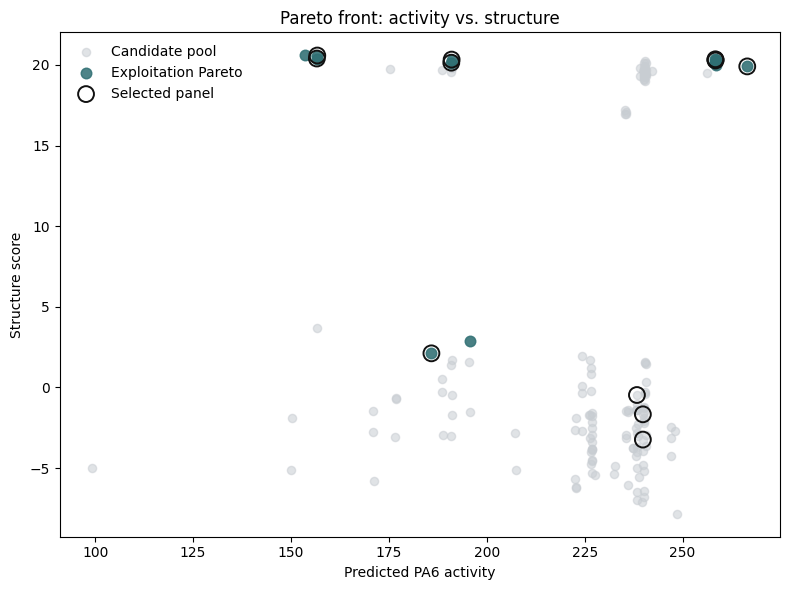

In [44]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    pool_plot["predicted_activity_gp_mean"],
    pool_plot["structure_score"],
    c="#c8cdd2",
    s=35,
    alpha=0.55,
    label="Candidate pool",
)
ax.scatter(
    exploitation_plot["predicted_activity_gp_mean"],
    exploitation_plot["structure_score"],
    c="#2f6f73",
    s=58,
    alpha=0.85,
    label="Exploitation Pareto",
)
ax.scatter(
    panel_plot["predicted_activity_gp_mean"],
    panel_plot["structure_score"],
    facecolors="none",
    edgecolors="#111111",
    s=130,
    linewidth=1.4,
    label="Selected panel",
)
ax.set_xlabel("Predicted PA6 activity")
ax.set_ylabel("Structure score")
ax.set_title("Pareto front: activity vs. structure")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(PARETRO_FIG_DIR / "pareto_activity_vs_structure.png", dpi=300, bbox_inches="tight")
plt.show()

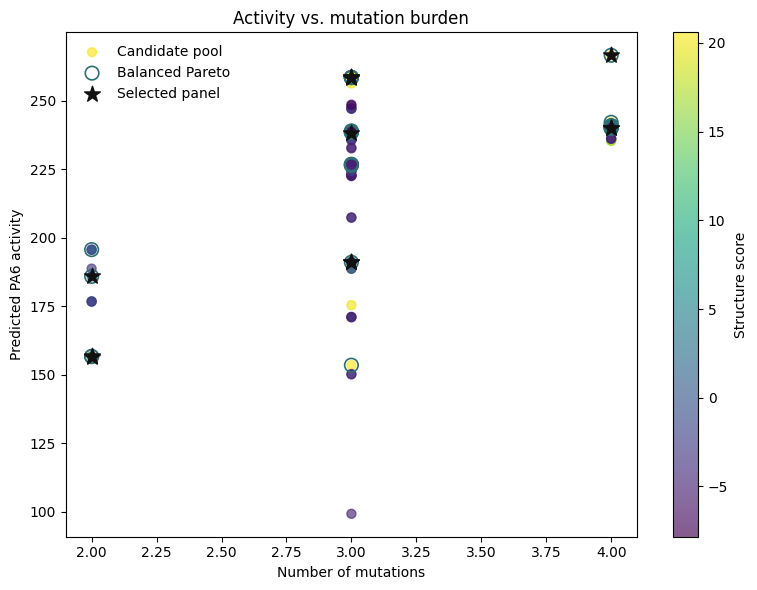

In [45]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    pool_plot["n_mutations"],
    pool_plot["predicted_activity_gp_mean"],
    c=pool_plot["structure_score"],
    cmap="viridis",
    s=42,
    alpha=0.65,
    label="Candidate pool",
)
ax.scatter(
    balanced_plot["n_mutations"],
    balanced_plot["predicted_activity_gp_mean"],
    facecolors="none",
    edgecolors="#2f6f73",
    s=95,
    linewidth=1.2,
    label="Balanced Pareto",
)
ax.scatter(
    panel_plot["n_mutations"],
    panel_plot["predicted_activity_gp_mean"],
    marker="*",
    c="#111111",
    s=140,
    label="Selected panel",
)
ax.set_xlabel("Number of mutations")
ax.set_ylabel("Predicted PA6 activity")
ax.set_title("Activity vs. mutation burden")
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Structure score")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(PARETRO_FIG_DIR / "pareto_activity_vs_mutation_count.png", dpi=300, bbox_inches="tight")
plt.show()

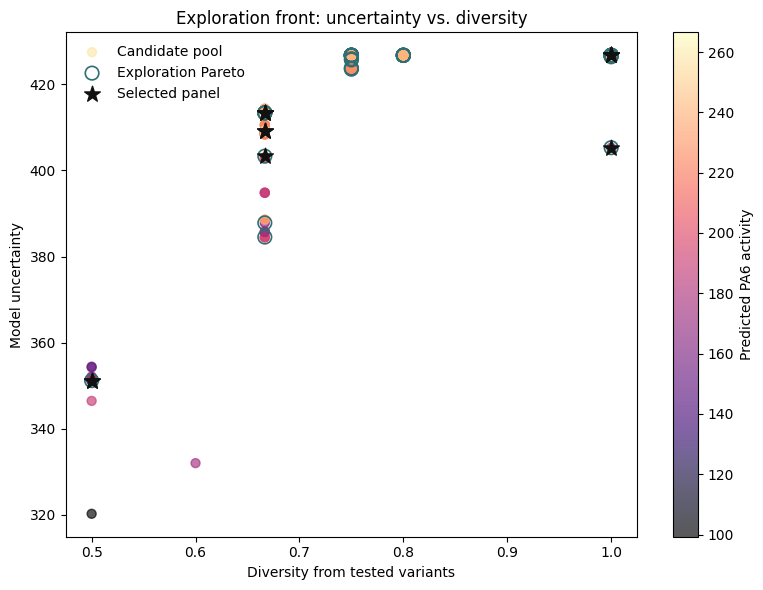

In [46]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    pool_plot["diversity_from_tested"],
    pool_plot["model_uncertainty"],
    c=pool_plot["predicted_activity_gp_mean"],
    cmap="magma",
    s=42,
    alpha=0.65,
    label="Candidate pool",
)
ax.scatter(
    exploration_plot["diversity_from_tested"],
    exploration_plot["model_uncertainty"],
    facecolors="none",
    edgecolors="#2f6f73",
    s=95,
    linewidth=1.2,
    label="Exploration Pareto",
)
ax.scatter(
    panel_plot["diversity_from_tested"],
    panel_plot["model_uncertainty"],
    marker="*",
    c="#111111",
    s=140,
    label="Selected panel",
)
ax.set_xlabel("Diversity from tested variants")
ax.set_ylabel("Model uncertainty")
ax.set_title("Exploration front: uncertainty vs. diversity")
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Predicted PA6 activity")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(PARETRO_FIG_DIR / "pareto_uncertainty_vs_diversity.png", dpi=300, bbox_inches="tight")
plt.show()

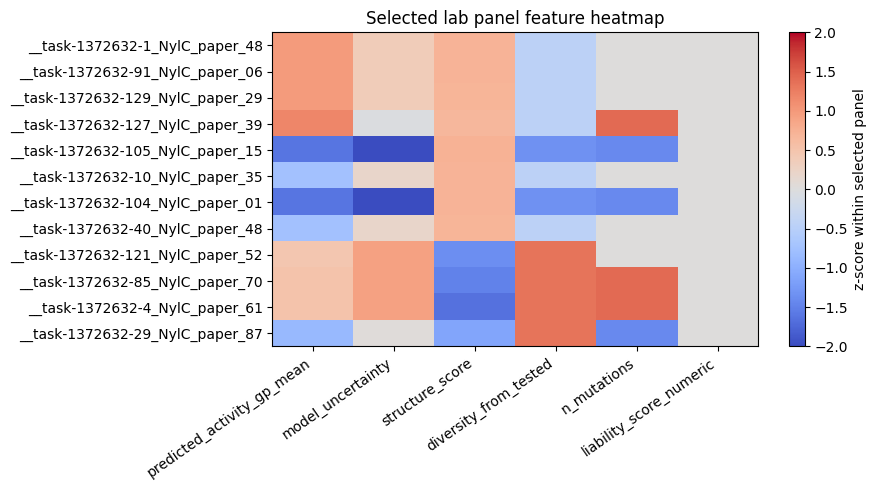

In [47]:
heat_cols = [
    "predicted_activity_gp_mean",
    "model_uncertainty",
    "structure_score",
    "diversity_from_tested",
    "n_mutations",
    "liability_score_numeric",
]
heat_cols = [col for col in heat_cols if col in panel_plot.columns]
heat_df = panel_plot.set_index("candidate_id")[heat_cols].apply(pd.to_numeric, errors="coerce")
heat_z = (heat_df - heat_df.mean()) / heat_df.std(ddof=0).replace(0, np.nan)
heat_z = heat_z.fillna(0.0)

fig, ax = plt.subplots(figsize=(9, max(5, 0.35 * len(heat_z))))
im = ax.imshow(heat_z.to_numpy(), aspect="auto", cmap="coolwarm", vmin=-2, vmax=2)
ax.set_xticks(np.arange(len(heat_cols)))
ax.set_xticklabels(heat_cols, rotation=35, ha="right")
ax.set_yticks(np.arange(len(heat_z)))
ax.set_yticklabels(heat_z.index)
ax.set_title("Selected lab panel feature heatmap")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("z-score within selected panel")
fig.tight_layout()
fig.savefig(PARETRO_FIG_DIR / "selected_panel_feature_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

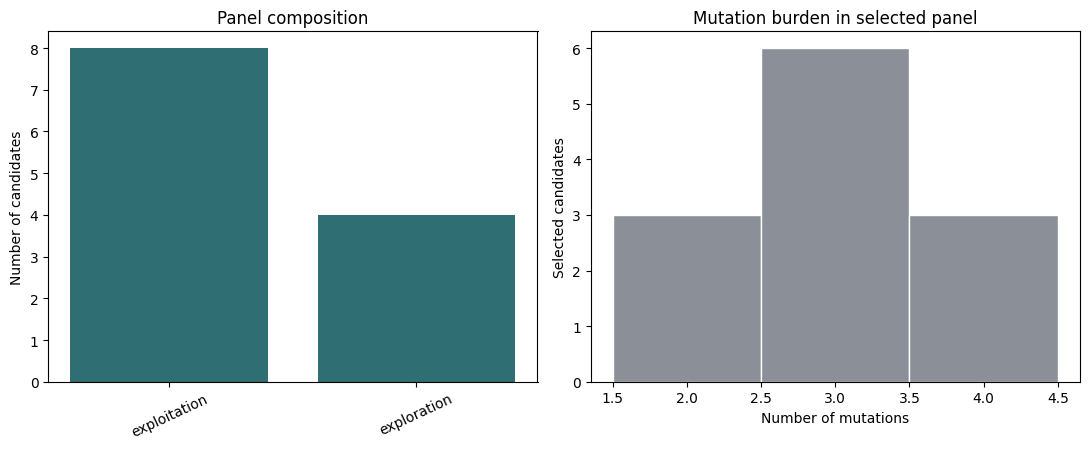

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
if "selection_bucket" in panel_plot.columns:
    bucket_counts = panel_plot["selection_bucket"].value_counts().sort_index()
    axes[0].bar(bucket_counts.index, bucket_counts.values, color="#2f6f73")
    axes[0].set_ylabel("Number of candidates")
    axes[0].set_title("Panel composition")
    axes[0].tick_params(axis="x", rotation=25)
else:
    axes[0].axis("off")

axes[1].hist(panel_plot["n_mutations"], bins=np.arange(panel_plot["n_mutations"].min(), panel_plot["n_mutations"].max() + 2) - 0.5, color="#8a8f98", edgecolor="white")
axes[1].set_xlabel("Number of mutations")
axes[1].set_ylabel("Selected candidates")
axes[1].set_title("Mutation burden in selected panel")
fig.tight_layout()
fig.savefig(PARETRO_FIG_DIR / "selected_panel_composition.png", dpi=300, bbox_inches="tight")
plt.show()